In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
path= '/content/drive/MyDrive/ML_DATASETS/energy.csv'

In [ ]:
data =pd.read_csv(path)

In [ ]:
print("First 5 rows:")
print(data.head())

First 5 rows:
             timestamp    load       temp
0  2012-01-01 00:00:00  2698.0  32.000000
1  2012-01-01 01:00:00  2558.0  32.666667
2  2012-01-01 02:00:00  2444.0  30.000000
3  2012-01-01 03:00:00  2402.0  31.000000
4  2012-01-01 04:00:00  2403.0  32.000000


In [ ]:
data['timestamp']= pd.to_datetime(data['timestamp'])

In [ ]:
data['time_num']= range(len(data))

In [ ]:
print("After adding time_num column:")
print(data.head(10))

After adding time_num column:
            timestamp    load       temp  time_num
0 2012-01-01 00:00:00  2698.0  32.000000         0
1 2012-01-01 01:00:00  2558.0  32.666667         1
2 2012-01-01 02:00:00  2444.0  30.000000         2
3 2012-01-01 03:00:00  2402.0  31.000000         3
4 2012-01-01 04:00:00  2403.0  32.000000         4
5 2012-01-01 05:00:00  2453.0  31.333333         5
6 2012-01-01 06:00:00  2560.0  30.000000         6
7 2012-01-01 07:00:00  2719.0  29.000000         7
8 2012-01-01 08:00:00  2916.0  29.000000         8
9 2012-01-01 09:00:00  3105.0  33.333333         9


In [ ]:
X= data[['time_num']]
y = data['load']

In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2,random_state=42)

In [ ]:
model= ExtraTreesRegressor()
model.fit(X_train, y_train)

ExtraTreesRegressor()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
rmse= np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

Model Accuracy:
R2   = 0.9826
MAE  = 53.5345
RMSE = 75.3948


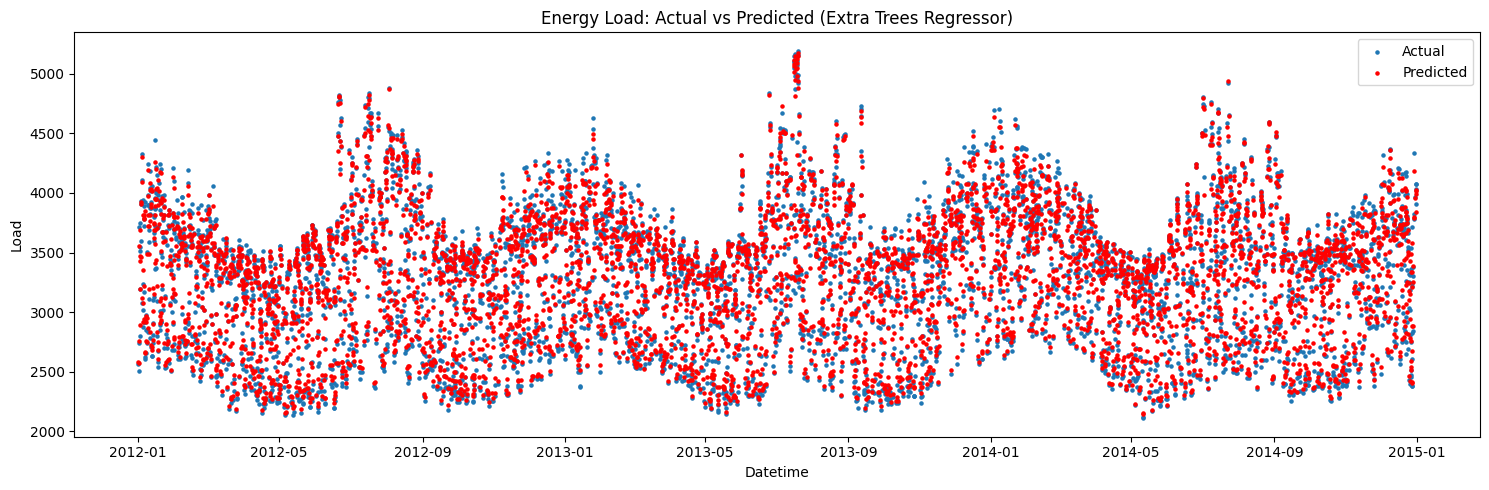

In [ ]:
print("Model Accuracy:")
print("R2   =", round(r2,4))
print("RMSE =", round(rmse,4))
print("MAE  =", round(mae,4))
plt.figure(figsize=(15, 5))
plt.scatter(data['timestamp'].iloc[X_test.index], y_test, s=5, label='Actual')
plt.scatter(data['timestamp'].iloc[X_test.index], y_pred, s=5, color='red',label='Predicted')
plt.xlabel('Datetime')
plt.ylabel('Load')
plt.title('Energy Load: Actual vs Predicted (Extra Trees Regressor)')
plt.legend()
plt.tight_layout()
plt.show()